### HALO Hackathon - EDA
The data being explored here is tracking enhanced data from 480 games in the 2023-2024 AHL season. 

The data is available in five separate datasets:
- `games`: one record per game with team and outcome information
- `events`: one record per event
- `stints`: one record per player per stint (a stretch of play during which a set of distinct players is on the ice)
- `players`: one record per player
- `tracking`: one record per player per event

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(style="darkgrid")

load_dotenv()
DATA = os.getenv("DATA")

EDA on `games_df`

In [2]:
games_df = pd.read_parquet(f"{DATA}/games.parquet")
print(games_df.shape)
print(games_df.dtypes)
games_df.head()

(480, 12)
game_id              str
game_date         object
league               str
season             int64
home_team            str
away_team            str
home_team_id         str
away_team_id         str
home_score         int64
away_score         int64
game_outcome         str
home_start_net       str
dtype: object


,game_id,game_date,league,season,home_team,away_team,home_team_id,away_team_id,home_score,away_score,game_outcome,home_start_net
0,0f51a5c7-6d54-1917-d4a5-9e83a0b4a1ea,2024-04-20,AHL,2023,CHI,IA,2fddd6bd-144f-ca64-90e3-8d36f96c8b28,50030ea0-2c9b-66e2-a36c-bab16b79492c,2,3,away_win,pos_x
1,0f1f9e60-c5cc-30e1-f520-e92f2da2ae08,2024-04-20,AHL,2023,BAK,HEN,19188913-73c8-34a7-d02a-5d1c3e58a191,411d86dc-8d7b-5507-c28d-87aa160b61cc,5,3,home_win,neg_x
2,1a0aceea-b3da-60e0-4c5c-0ba532fa6731,2024-04-20,AHL,2023,ABB,CAL,971502f4-80be-6e90-0bfb-3a60367a24ff,fbd255f8-427d-f29b-e83e-6c631c75899a,3,2,home_win,pos_x
3,609644d8-b5b8-8973-339a-53ca2c0d4ce1,2024-04-20,AHL,2023,HER,CLT,c1cd64c9-e2fd-7a1a-269a-aa5a8e422cbb,2251a5f6-9710-c610-8d44-9f2e4f4fc7a2,1,4,away_win,neg_x
4,2730a3bf-1f50-b700-7bd4-f01369b5e5cf,2024-04-20,AHL,2023,TEX,MB,9bfe142b-8c31-828f-dde8-a252d75d5ef3,1f9a39ec-18eb-166c-d1ed-5dfb9343f764,1,4,away_win,neg_x


In [3]:
print("Nulls per column:")
print(games_df.isna().sum())
print()
print(f"Date range: {games_df['game_date'].min()} to {games_df['game_date'].max()}")
print(f"League(s): {games_df['league'].unique()}")
print(f"Season(s): {games_df['season'].unique()}")
print(f"Teams: {games_df['home_team'].nunique()} unique")

Nulls per column:
game_id           0
game_date         0
league            0
season            0
home_team         0
away_team         0
home_team_id      0
away_team_id      0
home_score        0
away_score        0
game_outcome      0
home_start_net    0
dtype: int64

Date range: 2023-10-13 to 2024-04-21
League(s): <ArrowStringArray>
['AHL']
Length: 1, dtype: str
Season(s): [2023]
Teams: 32 unique


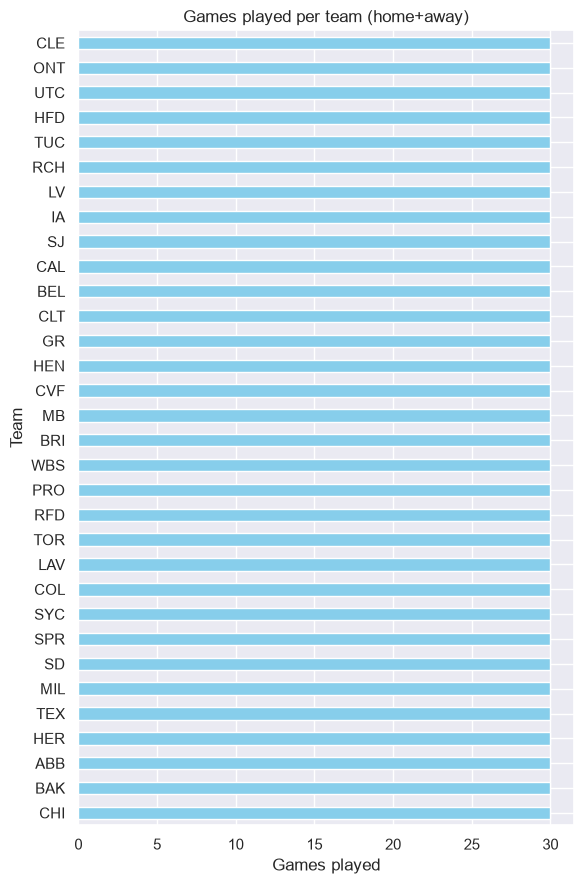

In [4]:
games_per_team = (
    pd.concat([games_df['home_team'], games_df['away_team']])
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(6, 9))
games_per_team.plot(kind="barh", ax=ax, color = "skyblue")
ax.set_xlabel("Games played")
ax.set_ylabel("Team")
ax.set_title("Games played per team (home+away)")
plt.tight_layout()
plt.show()

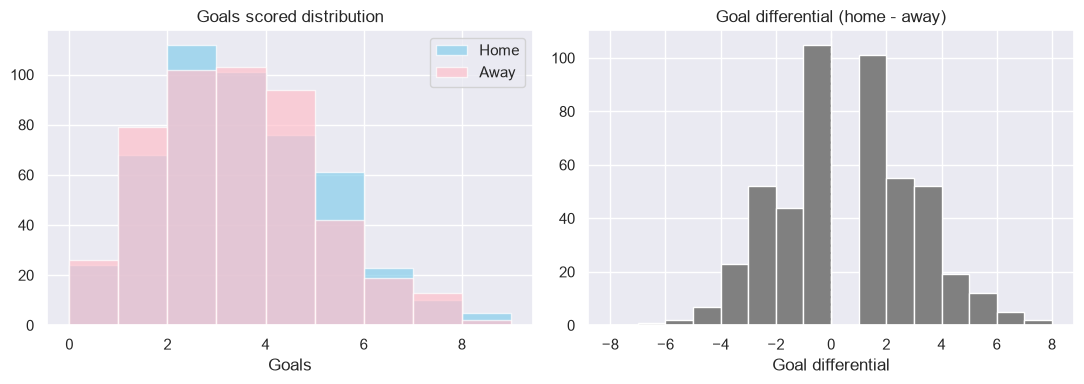

Mean total goals/game: 5.94


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(games_df["home_score"], bins=range(0, 10), alpha=0.7, label="Home", color="skyblue")
axes[0].hist(games_df["away_score"], bins=range(0, 10), alpha=0.7, label="Away", color="pink")
axes[0].set_title("Goals scored distribution")
axes[0].set_xlabel("Goals")
axes[0].legend()

goal_diff = games_df["home_score"] - games_df["away_score"]
axes[1].hist(goal_diff, bins=range(-8, 9), color="gray")
axes[1].axvline(0, color="white", linestyle="--", linewidth=1)
axes[1].set_title("Goal differential (home - away)")
axes[1].set_xlabel("Goal differential")
plt.tight_layout()
plt.show()

print(f"Mean total goals/game: {(games_df['home_score'] + games_df['away_score']).mean():.2f}")

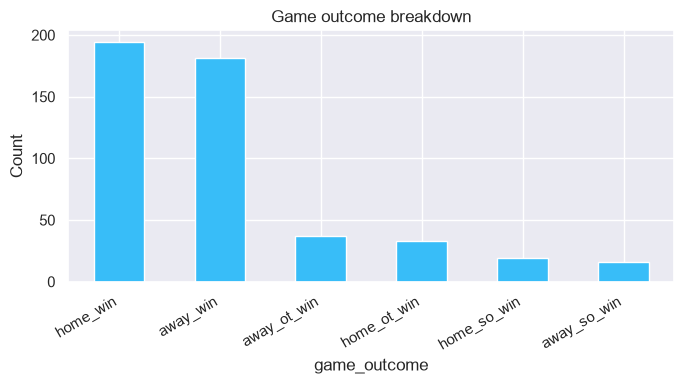

Home win rate (incl. OT/SO): 51.2%


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
games_df["game_outcome"].value_counts().plot(kind="bar", ax=ax, color="#38bdf8")
ax.set_title("Game outcome breakdown")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

home_win_types = {"home_win", "home_ot_win", "home_so_win"}
home_win_rate = games_df["game_outcome"].isin(home_win_types).mean()
print(f"Home win rate (incl. OT/SO): {home_win_rate:.1%}")

EDA on `players_df`